In [1]:
import squidpy as sq
import pandas as pd
import numpy as np
from src import clustering, graph_utils, plotting, LR
import spatialdata as sd
import os
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from napari_spatialdata import Interactive

c:\Users\laure\anaconda3\envs\new_spatial\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dirs = os.listdir("C://Users//laure//Desktop//github//sys_gen//zarr")
sdata = sd.read_zarr(f"C://Users//laure//Desktop//github//sys_gen//zarr//{dirs[4]}")
adata = sdata.tables["table"]

root_attr: version
root_attr: multiscales
datasets [{'path': '0', 'coordinateTransformations': [{'type': 'scale', 'scale': [1.0, 1.0]}]}, {'path': '1', 'coordinateTransformations': [{'type': 'scale', 'scale': [2.0000603682463023, 2.0]}]}, {'path': '2', 'coordinateTransformations': [{'type': 'scale', 'scale': [4.000362231345085, 4.000165439655886]}]}, {'path': '3', 'coordinateTransformations': [{'type': 'scale', 'scale': [8.00072446269017, 8.000992720052945]}]}, {'path': '4', 'coordinateTransformations': [{'type': 'scale', 'scale': [16.005314009661834, 16.00198544010589]}]}]
resolution: 0
 - shape ('y', 'x') = (33131, 48358)
 - chunks =  ['4096 (+ 363)', '4096 (+ 3302)']
 - dtype = uint32
resolution: 1
 - shape ('y', 'x') = (16565, 24179)
 - chunks =  ['4096 (+ 181)', '4096 (+ 3699)']
 - dtype = uint32
resolution: 2
 - shape ('y', 'x') = (8282, 12089)
 - chunks =  ['4096 (+ 90)', '4096 (+ 3897)']
 - dtype = uint32
resolution: 3
 - shape ('y', 'x') = (4141, 6044)
 - chunks =  ['4096 (+ 4

In [3]:
K = 1
graph_utils.get_distances(adata, k=K, log=True)
results = clustering.fit_gmm(adata, distance_key="1_nn_distance", k_range=range(1,10))
best_model_icl = clustering.choose_component(results, criterion="icl", delta_bic_threshold=10.0)
adata.obs["gmm_labels"] = best_model_icl["labels"]
LR.get_LR_pairs(adata)

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


Exception in thread Thread-7 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\laure\anaconda3\envs\new_spatial\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "c:\Users\laure\anaconda3\envs\new_spatial\Lib\site-packages\ipykernel\ipkernel.py", line 772, in run_closure
    _threading_Thread_run(self)
  File "c:\Users\laure\anaconda3\envs\new_spatial\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\laure\anaconda3\envs\new_spatial\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0x81 in position 120: invalid start byte


Fitted GMM with k=1
Fitted GMM with k=2
Fitted GMM with k=3
Fitted GMM with k=4
Fitted GMM with k=5
Fitted GMM with k=6
Fitted GMM with k=7
Fitted GMM with k=8
Fitted GMM with k=9
Detectable human interactions: 0
Detectable mouse interactions: 8


In [ ]:
adata.obs["gmm_labels"] = adata.obs["gmm_labels"].astype("category")


In [8]:
adata.obs

,cell_id,transcript_counts,control_probe_counts,control_codeword_counts,total_counts,cell_area,nucleus_area,region,1_nn_distance,gmm_labels
0,1,327,0,0,327,240.953750,63.038125,cell_circles,2.489137,3
1,2,354,0,0,354,211.692500,65.476562,cell_circles,2.530731,3
2,3,422,0,0,422,186.946875,69.540625,cell_circles,2.482289,3
3,4,250,0,0,250,239.237813,61.728594,cell_circles,2.558219,1
4,5,550,1,0,552,438.692969,92.209063,cell_circles,2.387596,3
...,...,...,...,...,...,...,...,...,...,...
162028,162029,555,0,0,557,515.955312,76.991406,cell_circles,2.840351,1
162029,162030,266,0,0,266,268.002344,13.637188,cell_circles,2.636120,1
162030,162031,488,0,1,489,346.483906,77.036563,cell_circles,2.273160,4
162031,162032,176,0,0,176,169.922969,9.889219,cell_circles,2.480262,3


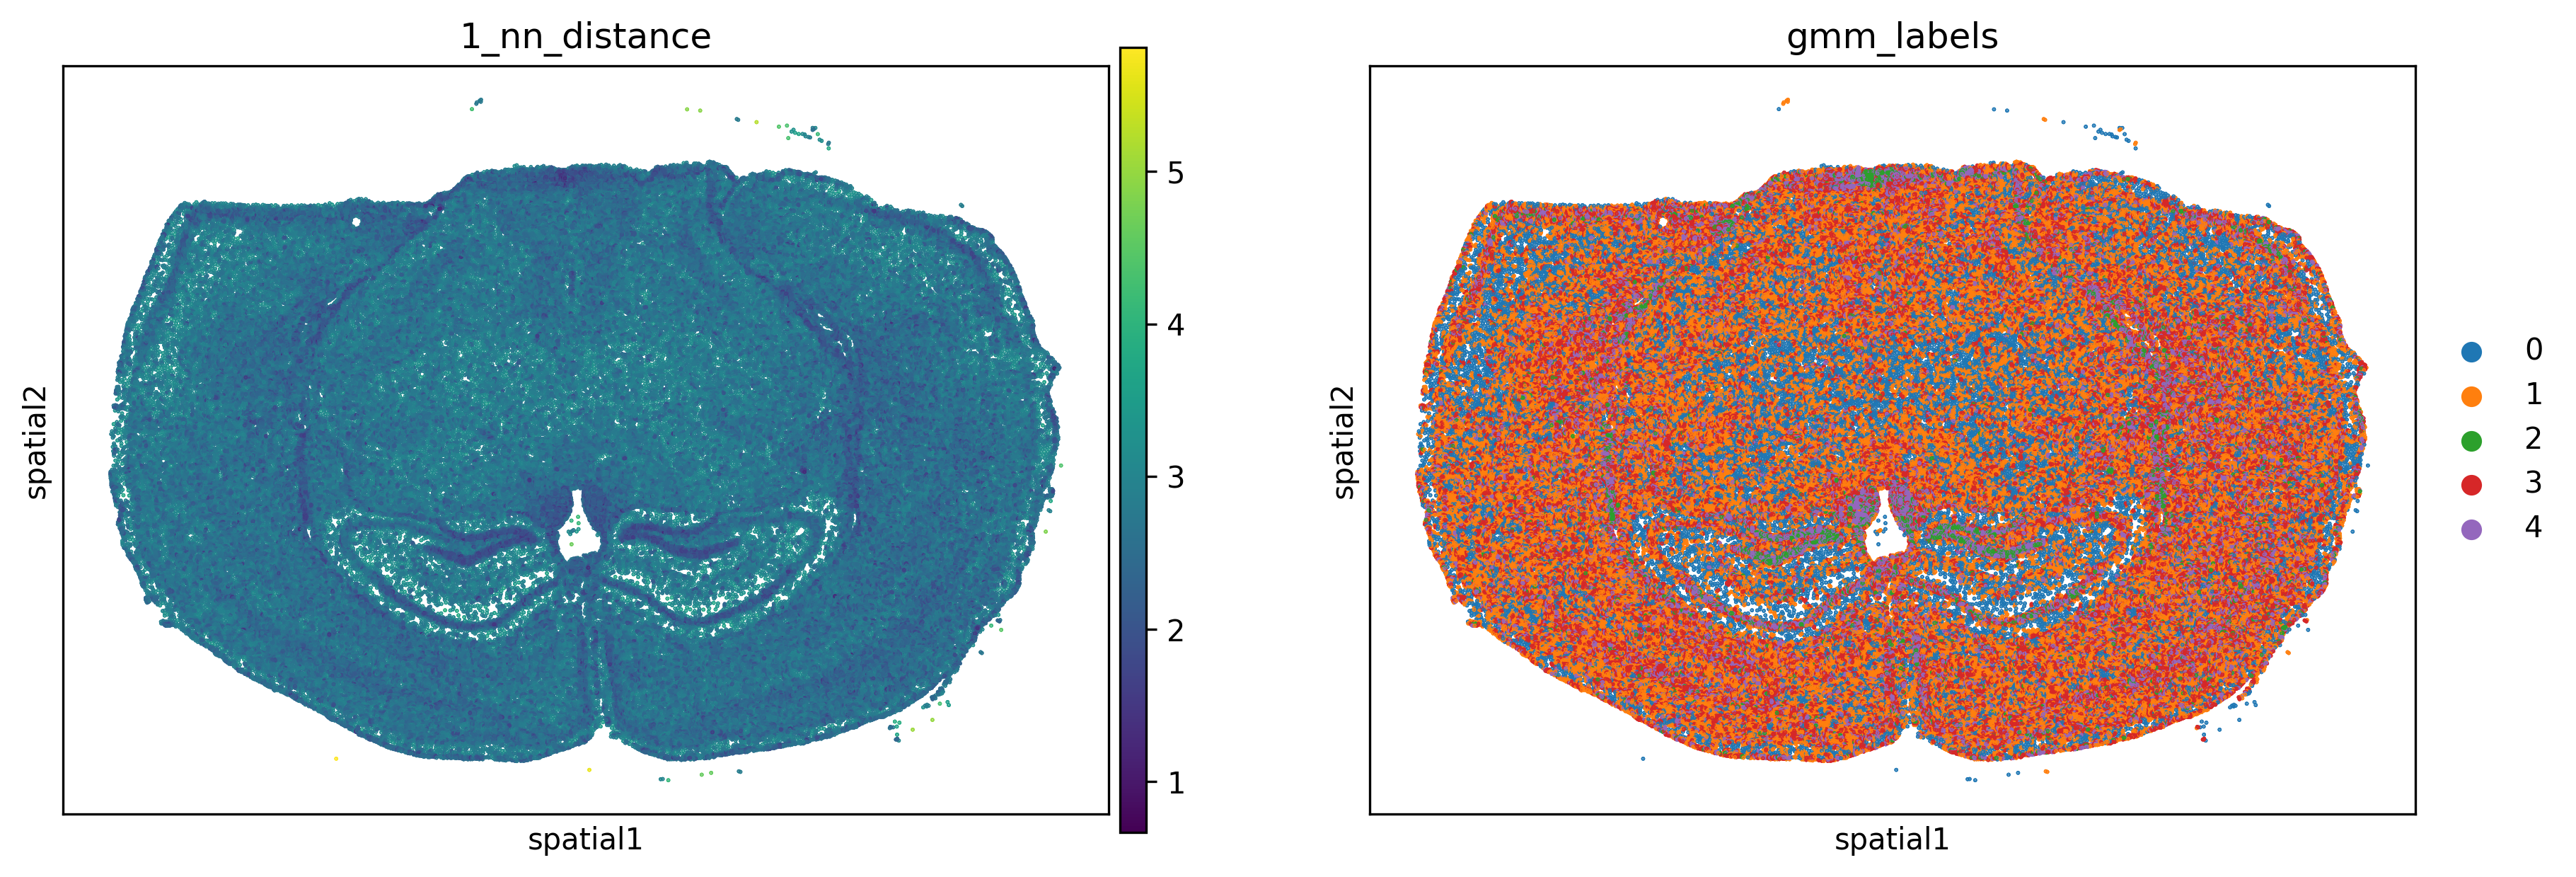

In [11]:
sq.pl.spatial_scatter(adata, color=["1_nn_distance","gmm_labels"], shape=None, save="distance_and_gmm_components.png", dpi=300, size=0.5)

In [22]:
import numpy as np
import matplotlib.pyplot as plt

def colored_distribution(
    df,
    value_col,
    cat_col,
    colors,
    bins=40,
    density=True,
    alpha=0.9
):
    """
    Plot one global distribution and color the contribution of each category.

    Parameters
    ----------
    df : pandas.DataFrame
    value_col : str
        Numeric column
    cat_col : str
        Categorical column
    colors : dict
        {category -> color}
    bins : int or sequence
    density : bool
        Normalize histogram
    """

    categories = list(df[cat_col].dropna().unique())

    data_per_cat = [
        df.loc[df[cat_col] == c, value_col].dropna().values
        for c in categories
    ]

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.hist(
        data_per_cat,
        bins=bins,
        stacked=True,
        density=density,
        color=[colors.get(c, "gray") for c in categories],
        label=categories,
        alpha=alpha
    )

    ax.set_ylabel("Density" if density else "Count")
    ax.set_xlabel(f"log {value_col}")
    ax.legend(title=cat_col)

    return fig, ax

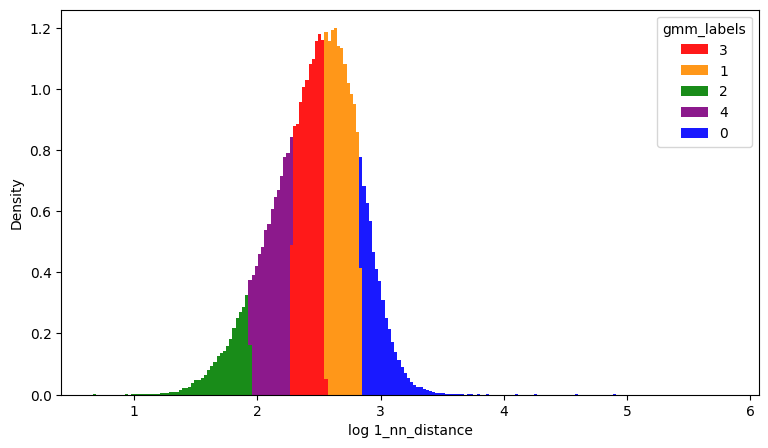

In [23]:
colors = {
    0: "blue",
    1: "darkorange",
    2: "green",
    3: "red",
    4: "purple"
}

fig, ax = colored_distribution(
    adata.obs,
    cat_col="gmm_labels",
    value_col="1_nn_distance",
    colors=colors,
    bins=200,
)
plt.show()